## Oppgave 4
### a)

Kopierer litt av koden din Erik, siden koden i 4b) bygger på 2.


In [344]:
import numpy as np
from matplotlib import pyplot as plt
import random
#programmet er strukturert slik at konstanter defineres først og brukes deretter globalt av funksjonene

"""Velger å ta med vegger på 0 og 80, slik at partiklene ikke kan hoppe fra start til slutt
Rett på meg hvis det blir feil."""

#konstanter
beta_k = 1000
# Spatial periods. Hvor mange steg før man er tilbake på en sagtanntopp.
Nx = 20
# Lengden på x-aksen. Har 4 sagtenner.    
L = 4*Nx
#Bruk periodisk boundary condition
Tp = 40 #Periode i tid. Så lenge gjelder potensial 1, før det bytter til potensial 2.
timeSteps = 10*Tp  # Skal være 10 i oppgaven

alfa = 0.2  # Faller mot høyre                   
# Total tid er 5 sykluser. Det betyr at Tp skal kjøre 10 ganger, siden to Tp er en syklus.
# Plot posisjon ved hvert tidssteg. Her bør jeg bruke en animasjon!!
# Passende x-akse?
x_axis = np.arange(0, 80, 81)
particleCount = 5     # Antall partikler.
particleSize = 5

# Bruker heller metoden fra tidligere, der partikkel i har poisjon x[i]
initParticlePos = np.linspace(0, 60, particleCount)   # Bruk L i midten!
listPosition = []

for n in range(len(initParticlePos)):
    listPosition.append(int(initParticlePos[n]))

print(initParticlePos)
print(listPosition)      # Bruker liste til å lagre posisjonene, for da vil vi kunne bruke det som indekser.

print(type(listPosition[0]))


[ 0. 15. 30. 45. 60.]
[0, 15, 30, 45, 60]
<class 'int'>


In [346]:
"""Må inkludere disse bibliotekene for å plotte."""
# !pip install pandas
# !pip install plotly

'Må inkludere disse bibliotekene for å plotte.'

### Oppretter funksjoner

In [ ]:
"""Oppretter først funksjonene. Definerer så variablene."""

# Bruker liste til å lagre posisjonene, for da vil vi kunne bruke det som indekser.
def MakeParticles(params):   #Diverse sjekker, om posisjoner er tillatt, slik at koden fungerer.
    size = params["b"]
    count = params["Np"]
    L = params["L"]
    initParticlePos = np.linspace(0, L-2*size, count)
    listPosition = []

    for n in range(len(initParticlePos)):
        listPosition.append(int(initParticlePos[n]))
    return listPosition

def occupied(particlePos, params):
    particleCount = params["Np"]
    particleSize = params["b"]
    L = params["L"]
    occupiedMatrix = np.zeros((particleCount, 3))    
    """occupiedMatrix[i][0] = partikkels senter, occupiedMatrix[i][1] = venstre, occupiedMatrix[i][2] = høyre
    Kan endres på dersom noe annet gir mer mening."""
    for pos in range(len(particlePos)):
        occupiedMatrix[pos][0] = particlePos[pos]
        occupiedMatrix[pos][1] = (particlePos[pos] - (particleSize) // 2) % L
        occupiedMatrix[pos][2] = (particlePos[pos] + (particleSize) // 2) % L
    return occupiedMatrix

print(occupied(listPosition))

In [333]:
#Potensialer
def V1(x):                #uten k fordi den inngår i p_pos
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return (periode-Nx)/((1-alfa)*Nx)

def V2(x):                          #også uten k for samme grunn
    return 0

In [334]:
#Henholdsvise sannsynlighetsfunksjoner p+, p0 og p-
def p_pos(x, V):

    #får litt numerisk overflow hvis jeg ikke clipper
    arg1 = np.clip(-beta_k*(V((x-1)%L)-V((x+1)%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L)-V((x+1)%L)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner


def p_0(x, V):

    arg1 = np.clip(-beta_k*(V((x-1)%L)-V(x%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V((x+1)%L)-V(x%L)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


def p_neg(x, V):

    arg1 = np.clip(-beta_k*(V((x+1)%L)-V((x-1)%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L)-V((x-1)%L)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner

def lookUpTabell_V1():
    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    V = V1    # Her bruker vi potensial V1!
    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V)
        tabell_V1_p_neg[x] = p_neg(x, V)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2():
    p_pos_val = p_pos(1, V2)
    p_neg_val = p_neg(1, V2)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg

Legger inn alle variable, tabeller, og initialverdiposisjoner.

In [335]:
params4a = {
    "alfa"      : 0.2,
    "Tp"        : 40,       # Tid for 0.5 periode
    "Nx"        : 20,
    "beta_k"    : 1000,
    "Np"        : 8,        # Velg et fint antall
    "b"         : 6,        # Størrelse. Velg en fin størrelse. Kan lage en funksjon her.
}
params4a["L"] = 4*params4a["Nx"]
params4a["timeSteps"] = 10*params4a["Tp"]


#lager look up tabell som gjør at ting går mye raskere
tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1()
tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2()

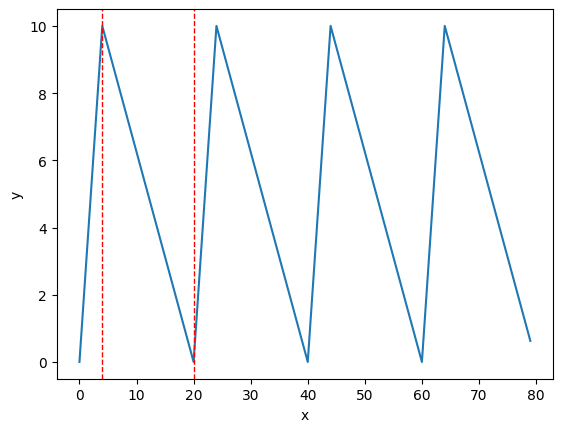

In [336]:
""" Du trenger ikke ha med dette Johannes"""

# Prøver å forstå alt sammen. Tegner potensialet.
# Må modifisere litt. Kan ikke sammenligne et helt array med periode, siden hver verdi for forskjellig bool-verdi.

alfa = 0.2
def V1_test(x):
    potensialer = np.zeros_like(x, dtype = float)    # Viktig å endre datatype. Hvis ikke blir verdiene til int.
    for i in range(len(x)):
        Hvor_i_periode = x[i] % params4a["Nx"]
        if Hvor_i_periode <= alfa*params4a["Nx"]:
            potensialer[i] = 10*Hvor_i_periode / (alfa* params4a["Nx"])
        else:
            potensialer[i] = -10*(Hvor_i_periode - params4a["Nx"])/((1-alfa)*params4a["Nx"]) 
    return potensialer
    
x_axis = np.arange(0, params4a["L"], 1)
y_potential = V1_test(x_axis)
plt.plot(x_axis, V1_test(x_axis))
plt.xlabel("x")
plt.ylabel("y")
plt.axvline(x=4, color='red', linestyle='--', linewidth=1, label='x=2')
plt.axvline(x=20, color='red', linestyle='--', linewidth=1, label='x=20')
plt.show()

In [337]:
# Optimalisering. Siden partiklene bare kan bevege steg med lengde 1,
# så behøver vi bare å sjekke forrige/neste partikkel.

def enSimulasjon_4a():
    positionsOverTime = []
    particlePos = listPosition.copy()
    print(particlePos)
    rightIndex = 2
    leftIndex = 1
    queue = list(range(particleCount))
    print(type(queue[2]))
    
    occupiedMatrix = occupied(particlePos)
    positionsOverTime.append(particlePos.copy())

    for k in range(timeSteps):
        random.shuffle(queue)
        whichPotential = ( k // Tp) % 2    
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        for index in queue:
            tilfeldigtall = np.random.rand()
            x = particlePos[index]                            # Må sjekke kollisjon for hver partikkel
            # print(x)
            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if (x-1) == occupiedMatrix[index-1][rightIndex]:
                    continue
                x -= 1
            elif tilfeldigtall >= (1 - tabell_p_pos[ x% L]):
                if (x+1) == occupiedMatrix[(index + 1) % particleCount][leftIndex]:
                    continue
                x += 1
            particlePos[index] = x % (L)                      # Hopper tilbake til start.
            occupiedMatrix = occupied(particlePos)
    
            # print(particlePos)
        positionsOverTime.append(particlePos.copy())
    return positionsOverTime

positions_Over_Time = enSimulasjon_4a()

print(len(positions_Over_Time))
print(positions_Over_Time[0], positions_Over_Time[200], positions_Over_Time[400])

In [ ]:
import plotly.graph_objects as go

# Example: list of position snapshots over time
# Each inner list = positions of balls at that timestep
positions_over_time = positions_Over_Time
print(positions_over_time)

num_balls = len(positions_over_time[0])
Tp = params4a["Tp"]

# Create frames
frames = []
for t, positions in enumerate(positions_over_time):
    frame = go.Frame(
        data=[
            go.Scatter(
                x=positions,
                y=[0]*num_balls,  # all balls on same horizontal line
                mode="markers",
                marker=dict(size=12)
            )
        ],
        name=str(t)
    )
    frames.append(frame)

# Initial figure
fig = go.Figure(
    data=[
        go.Scatter(
            x=positions_over_time[0],
            y=[0]*num_balls,
            mode="markers",
            marker=dict(size=12)
        )
    ],
    frames=frames
)

# Tegner andre figurer? 
fig.update_layout(
    shapes=[
        dict(
            type="rect",
            x0=pos-particleSize//2,
            x1=pos+particleSize//2,
            y0=-particleSize//2,
            y1=particleSize//2,
            fillcolor="blue"
        )
        for pos in positions
    ]
)

# Add play button
fig.update_layout(
    xaxis=dict(range=[0, L], title="Position"),
    yaxis=dict(range=[-10, 10], visible=False),
    updatemenus=[
        dict(
            type="buttons",
            buttons=[
                dict(
                    label="Play",
                    method="animate",
                    args=[None, {"frame": {"duration": 200, "redraw": True},
                                 "fromcurrent": True}]
                )
            ]
        )
    ]
)

fig.show()

[[0, 15, 30, 45, 60], [1, 15, 31, 46, 61], [1, 16, 32, 47, 61], [0, 16, 33, 46, 60], [1, 17, 32, 45, 59], [2, 18, 32, 44, 58], [1, 19, 32, 43, 58], [2, 20, 32, 44, 58], [2, 19, 32, 44, 57], [1, 20, 31, 44, 57], [2, 21, 30, 44, 58], [1, 20, 29, 43, 58], [2, 20, 30, 43, 59], [1, 20, 30, 43, 58], [0, 19, 29, 42, 58], [79, 20, 29, 41, 58], [78, 19, 29, 40, 58], [77, 20, 30, 41, 58], [78, 19, 30, 40, 59], [79, 18, 29, 41, 60], [0, 18, 30, 40, 61], [1, 17, 31, 39, 62], [2, 17, 30, 39, 63], [3, 16, 29, 39, 63], [2, 17, 29, 39, 62], [2, 18, 28, 39, 61], [3, 18, 28, 40, 60], [2, 19, 28, 40, 59], [3, 19, 29, 40, 58], [2, 19, 29, 40, 58], [1, 19, 29, 40, 57], [0, 19, 28, 39, 58], [0, 19, 27, 39, 58], [1, 20, 26, 38, 58], [0, 20, 27, 39, 57], [1, 20, 26, 39, 56], [1, 19, 25, 40, 55], [1, 19, 24, 40, 55], [0, 18, 25, 39, 55], [79, 19, 25, 39, 55], [0, 18, 26, 38, 54], [79, 17, 25, 37, 53], [78, 16, 25, 36, 52], [77, 15, 25, 35, 51], [76, 14, 25, 34, 50], [75, 13, 25, 33, 49], [74, 12, 25, 32, 48], 

#### Oppgave 4b)

Legger inn flere funksjoner

In [ ]:
def rho(b, Np, Ns, Nx):
    return b*Np/(Ns*Nx)

In [339]:
params4b = {
    "beta_k"  : 1000,
    "Nx"      : 100,
    "Tp"      : 300,
    "Ns"      : 10,
    "alfa"    : 0.2,
    "b"       : 20,   # Størrelse på partiklene.
    "Nc"      : 100,  # Antall sykler. For hver tetthet.
    "Np"      : 7 # Denne skal varieres for å danne forskjellige tetthet rho.
}
params4b["rho"] = rho(params4b["b"], params4b["Np"],params4b["Ns"],params4b["Nc"])

In [341]:
def particleCurrent_sim(partiklerPos, params, tabeller):
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    Np = params["Np"]
    startPot_pos_table = tabeller["startPot_pos_table"]
    startPot_neg_table = tabeller["startPot_neg_table"]
    secondPot_pos_table = tabeller["secondPot_pos_table"]
    secondPot_neg_table = tabeller["secondPot_neg_table"]

    particleCurrent = np.zeros(timeSteps)

    for k in range(timeSteps):
        hvilkenPotensial = ( k // Tp) % 2    
        n_pos = 0
        n_neg = 0
        if hvilkenPotensial == 0:
            tabell_p_pos, tabell_p_neg = startPot_pos_table, startPot_neg_table
        else:
            tabell_p_pos, tabell_p_neg = secondPot_pos_table, secondPot_neg_table
        
        randomtabell = np.random.rand(Np)

        posProb = tabell_p_pos[partiklerPos]
        negProb = tabell_p_neg[partiklerPos]

        neg_flytt = (randomtabell <= negProb)
        pos_flytt = (~neg_flytt) & (randomtabell >= (1 - posProb))

        partiklerPos[neg_flytt] -= 1
        partiklerPos[pos_flytt] += 1
        partiklerPos %= L

        # for i in range(len(partiklerPos)):
        #         x = partiklerPos[i]

        #         if randomtabell[i] <= tabell_p_neg[x]:      
        #             x -= 1                                
        #             n_neg += 1                            
        #         elif randomtabell[i] >= (1 - tabell_p_pos[x]):
        #             x += 1
        #             n_pos += 1
        #         partiklerPos[i] = x % (L)

        n_pos = pos_flytt.sum()
        n_neg = neg_flytt.sum()
        particleCurrent[k] = (n_pos - n_neg)/Np

    return particleCurrent

In [347]:
# Optimalisering. Siden partiklene bare kan bevege steg med lengde 1,
# så behøver vi bare å sjekke forrige/neste partikkel.

def enSimulasjon_4b():
    positionsOverTime = []
    particlePos = initPositions.copy()
    rightIndex = 2
    leftIndex = 1
    n_pos = 0
    n_neg = 0
    queue = list(range(particleCount))
    particleCurrent = np.zeros(300*100)
    
    occupiedMatrix = occupied(particlePos)
    positionsOverTime.append(particlePos.copy())

    for k in range(timeSteps):
        random.shuffle(queue)
        whichPotential = ( k // Tp) % 2    
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        for index in queue:
            tilfeldigtall = np.random.rand()
            x = particlePos[index]                            # Må sjekke kollisjon for hver partikkel
            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if (x-1) == occupiedMatrix[index-1][rightIndex]:
                    continue
                x -= 1
                n_neg += 1
            elif tilfeldigtall >= (1 - tabell_p_pos[x% L]):
                if (x+1) == occupiedMatrix[(index + 1) % particleCount][leftIndex]:
                    continue
                x += 1
                n_pos += 1
            particlePos[index] = x % (L)                      # Hopper tilbake til start.
            occupiedMatrix = occupied(particlePos)
        particleCurrent[k] = (n_pos - n_neg)/Np

    return particleCurrent

strøm = enSimulasjon_4b()
print(strøm)

TypeError: occupied() missing 1 required positional argument: 'params'

In [ ]:
x_strøm =np.arange(Tp)
plt.plot(x_strøm, strøm)

plt.show()